# sdfsdf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### 01 - Probabilidade clássica: de 500 clientes, 60 estão inadimplentes. Calcule P(inadimplente) e P(adimplente | renda alta)

In [2]:
# Dados da tabela:
total_clientes = 500
inadimplentes = 60
renda_alta_adimplente = 180
renda_alta_total = 220

p_inadimplente = inadimplentes / total_clientes
p_adimplente_dado_renda_alta = renda_alta_adimplente / renda_alta_total

print(f"1. P(Inadimplente) = {p_inadimplente:.4f} ({p_inadimplente*100:.2f}%)")
print(f"2. P(Adimplente | Renda Alta) = {p_adimplente_dado_renda_alta:.4f} ({p_adimplente_dado_renda_alta*100:.2f}%)")

1. P(Inadimplente) = 0.1200 (12.00%)
2. P(Adimplente | Renda Alta) = 0.8182 (81.82%)


### 02 - Binomial: em um lote de 20 novos clientes (P(inadimplência)=12%), calcule P(exatamente 2 inadimplentes) e P(mais de 4)

In [4]:
n = 20
p = 0.12

p_exatamente_2 = stats.binom.pmf(2, n, p)
p_mais_de_4 = stats.binom.sf(4, n, p)

print(f"1. P(X = 2) = {p_exatamente_2:.4f} ({p_exatamente_2*100:.2f}%)")
print(f"2. P(X > 4) = {p_mais_de_4:.4f} ({p_mais_de_4*100:.2f}%)")

1. P(X = 2) = 0.2740 (27.40%)
2. P(X > 4) = 0.0827 (8.27%)


### 03 - Poisson: o banco recebe em média 3 solicitações de empréstimo por hora. Calcule P(0 solicitações em 1h) e P(mais de 6)

In [5]:
lmbda = 3

p_zero_solicitacoes = stats.poisson.pmf(0, lmbda)
p_mais_de_6 = stats.poisson.sf(6, lmbda)

print(f"1. P(X = 0 em 1h) = {p_zero_solicitacoes:.4f} ({p_zero_solicitacoes*100:.2f}%)")
print(f"2. P(X > 6 em 1h) = {p_mais_de_6:.4f} ({p_mais_de_6*100:.2f}%)")

1. P(X = 0 em 1h) = 0.0498 (4.98%)
2. P(X > 6 em 1h) = 0.0335 (3.35%)


### 04 - Normal: score de crédito segue N(650, 80). Calcule P(score > 700) e o score mínimo para estar nos top 10%

In [6]:
mu = 650
sigma = 80

p_score_maior_700 = stats.norm.sf(700, loc=mu, scale=sigma)
score_minimo_top10 = stats.norm.ppf(0.90, loc=mu, scale=sigma)

print(f"1. P(Score > 700) = {p_score_maior_700:.4f} ({p_score_maior_700*100:.2f}%)")
print(f"2. Score mínimo para estar nos top 10%: {score_minimo_top10:.2f}")

1. P(Score > 700) = 0.2660 (26.60%)
2. Score mínimo para estar nos top 10%: 752.52


### 05 - Bayes: P(fraude)=0,5%, P(alerta|fraude)=92%, P(alerta|legítima)=4%. Calcule P(fraude|alerta)

In [7]:
p_fraude = 0.005
p_legitima = 1 - p_fraude
p_alerta_dado_fraude = 0.92
p_alerta_dado_legitima = 0.04

p_alerta = (p_alerta_dado_fraude * p_fraude) + (p_alerta_dado_legitima * p_legitima)
p_fraude_dado_alerta = (p_alerta_dado_fraude * p_fraude) / p_alerta

print(f"P(Fraude | Alerta) = {p_fraude_dado_alerta:.4f} ({p_fraude_dado_alerta*100:.2f}%)")

P(Fraude | Alerta) = 0.1036 (10.36%)


### 06 - Monte Carlo: simule 50.000 cenários de inadimplência (n=500, p=0,12) e plote a distribuição. Qual o VaR 95%?

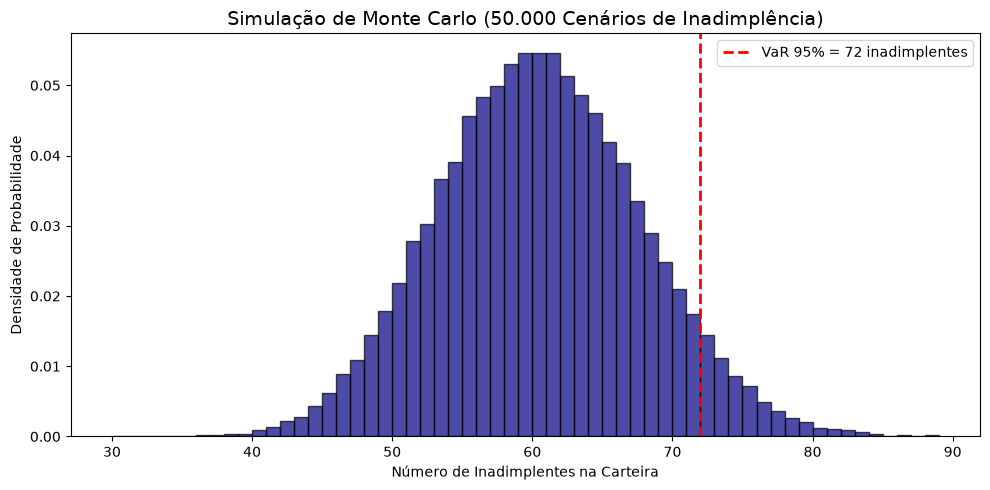

VaR 95%: Em 95% dos cenários, o número de inadimplentes não passará de 72 clientes.


In [8]:
np.random.seed(42)

n_clientes = 500
p_inadimplencia = 0.12
n_simulacoes = 50000

cenarios_inadimplentes = np.random.binomial(n=n_clientes, p=p_inadimplencia, size=n_simulacoes)
var_95 = np.percentile(cenarios_inadimplentes, 95)

plt.figure(figsize=(10, 5))
plt.hist(cenarios_inadimplentes, bins=range(30, 90), density=True, alpha=0.7, color='navy', edgecolor='black')
plt.axvline(var_95, color='red', linestyle='--', linewidth=2, label=f'VaR 95% = {int(var_95)} inadimplentes')
plt.title('Simulação de Monte Carlo (50.000 Cenários de Inadimplência)', fontsize=14)
plt.xlabel('Número de Inadimplentes na Carteira')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.tight_layout()
plt.show()

print(f"VaR 95%: Em 95% dos cenários, o número de inadimplentes não passará de {int(var_95)} clientes.")

### 07 - Visualização: plote as distribuições Binomial, Poisson e Normal em subplots

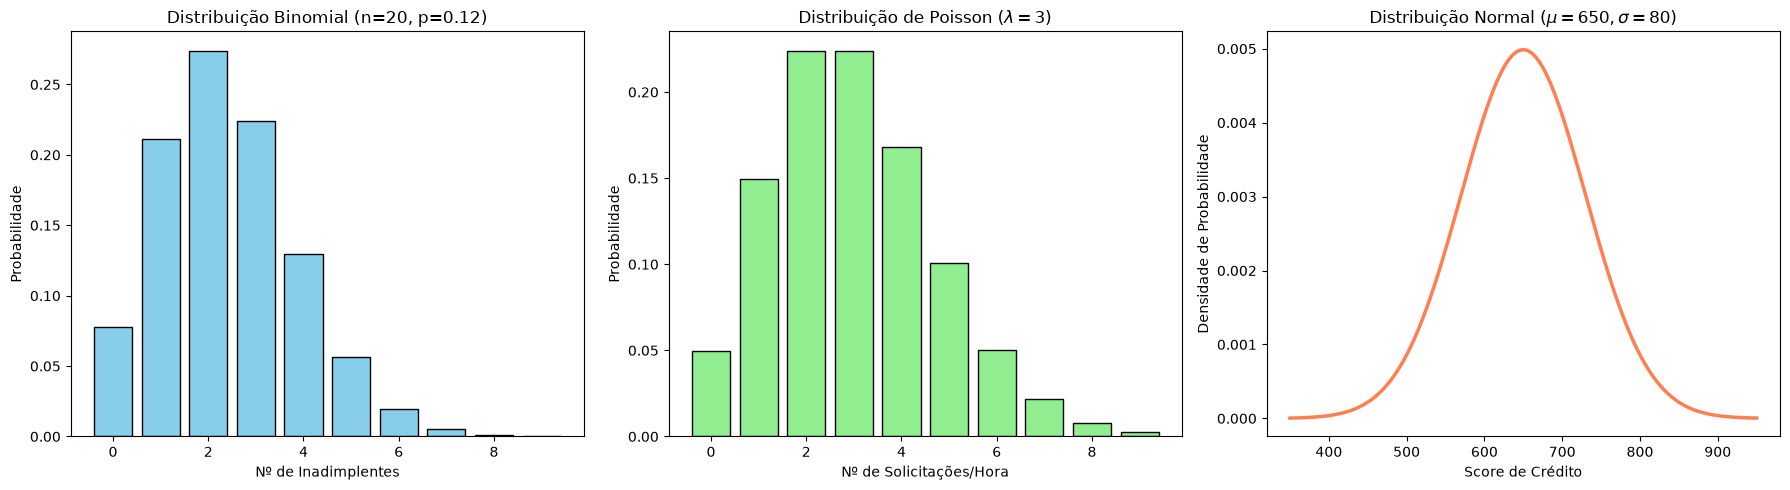

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_binom = np.arange(0, 10)
y_binom = stats.binom.pmf(x_binom, 20, 0.12)
axes[0].bar(x_binom, y_binom, color='skyblue', edgecolor='black')
axes[0].set_title('Distribuição Binomial (n=20, p=0.12)')
axes[0].set_xlabel('Nº de Inadimplentes')
axes[0].set_ylabel('Probabilidade')

x_poisson = np.arange(0, 10)
y_poisson = stats.poisson.pmf(x_poisson, 3)
axes[1].bar(x_poisson, y_poisson, color='lightgreen', edgecolor='black')
axes[1].set_title(r'Distribuição de Poisson ($\lambda=3$)')
axes[1].set_xlabel('Nº de Solicitações/Hora')
axes[1].set_ylabel('Probabilidade')

x_norm = np.linspace(350, 950, 500)
y_norm = stats.norm.pdf(x_norm, 650, 80)
axes[2].plot(x_norm, y_norm, color='coral', linewidth=2.5)
axes[2].set_title(r'Distribuição Normal ($\mu=650, \sigma=80$)')
axes[2].set_xlabel('Score de Crédito')
axes[2].set_ylabel('Densidade de Probabilidade')

plt.tight_layout()
plt.show()